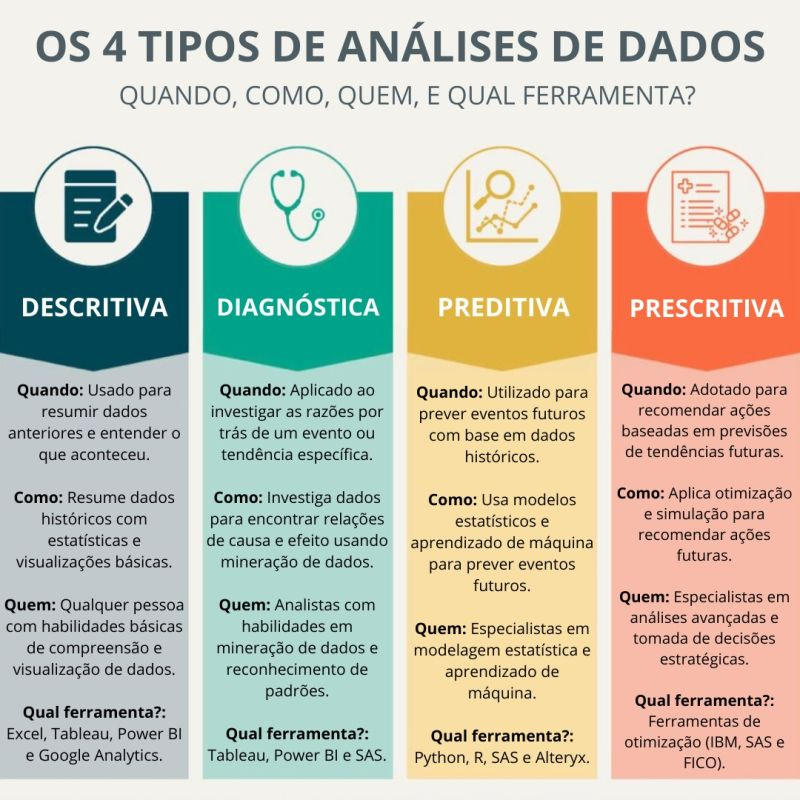

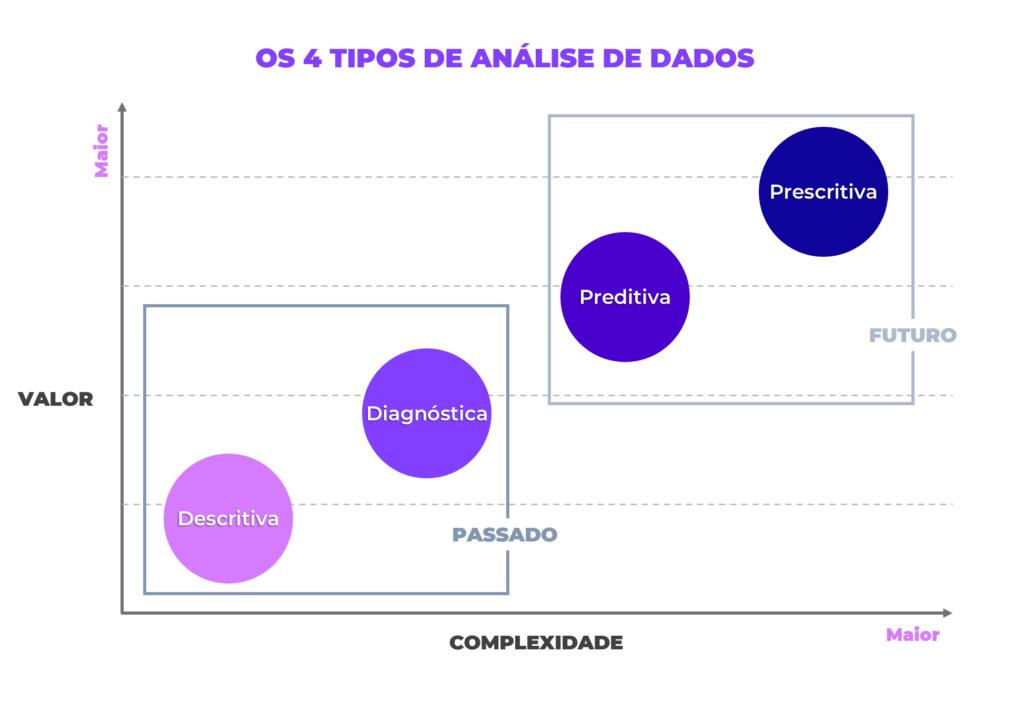

In [275]:
import pandas as pd

In [276]:
# importando Dados

In [277]:
df_vendas1 = pd.read_csv('/content/drive/MyDrive/DATA PYHON 2604/datasets/base_dados_vendas_tratada.csv', parse_dates=['dt_venda','dt_entrega'])

In [278]:
df_vendas2 = pd.read_csv('/content/drive/MyDrive/DATA PYHON 2604/datasets/dados_complementares.csv', parse_dates=['dt_venda','dt_entrega'])

In [279]:
df_metas = pd.read_excel('/content/drive/MyDrive/DATA PYHON 2604/datasets/Python_JOIN_Metas.xlsx')

In [280]:
df_vendas1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               3000 non-null   datetime64[ns]
 1   matricula_funcionario  3000 non-null   int64         
 2   nome_funcionario       3000 non-null   object        
 3   cargo                  3000 non-null   object        
 4   codigo_loja            3000 non-null   object        
 5   nome_loja              3000 non-null   object        
 6   codigo_produto         3000 non-null   int64         
 7   descricao_produto      3000 non-null   object        
 8   categoria              3000 non-null   object        
 9   preco_custo            3000 non-null   float64       
 10  valor_unitario         3000 non-null   float64       
 11  quantidade             3000 non-null   int64         
 12  dt_entrega             3000 non-null   datetime64[ns]
 13  val

In [281]:
df_vendas2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               500 non-null    datetime64[ns]
 1   matricula_funcionario  500 non-null    int64         
 2   nome_funcionario       500 non-null    object        
 3   cargo                  500 non-null    object        
 4   codigo_loja            500 non-null    object        
 5   nome_loja              500 non-null    object        
 6   codigo_produto         500 non-null    int64         
 7   descricao_produto      500 non-null    object        
 8   categoria              500 non-null    object        
 9   preco_custo            500 non-null    float64       
 10  valor_unitario         500 non-null    float64       
 11  quantidade             500 non-null    int64         
 12  dt_entrega             500 non-null    datetime64[ns]
 13  valor

In [282]:
df_metas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ano     24 non-null     int64
 1   mes     24 non-null     int64
 2   meta    24 non-null     int64
dtypes: int64(3)
memory usage: 708.0 bytes


In [283]:
print(f'''
    Vendas1: {df_vendas1.shape}
    Vendas2: {df_vendas2.shape}
    Metas: {df_metas.shape}
''')


    Vendas1: (3000, 14)
    Vendas2: (500, 14)
    Metas: (24, 3)



In [284]:
df_vendas1.isnull().sum()

,0
dt_venda,0
matricula_funcionario,0
nome_funcionario,0
cargo,0
codigo_loja,0
nome_loja,0
codigo_produto,0
descricao_produto,0
categoria,0
preco_custo,0


In [285]:
df_vendas2.isnull().sum()

,0
dt_venda,0
matricula_funcionario,0
nome_funcionario,0
cargo,0
codigo_loja,0
nome_loja,0
codigo_produto,0
descricao_produto,0
categoria,0
preco_custo,0


In [286]:
df_metas.isnull().sum()

,0
ano,0
mes,0
meta,0


In [287]:
# VALORES ESTATÍSTICOS

In [288]:
df_vendas1[['preco_custo','valor_unitario','quantidade','valor_final']].describe().round(2)

,preco_custo,valor_unitario,quantidade,valor_final
count,3000.00,3000.00,3000.00,3000.00
mean,545.51,926.94,2.45,2234.95
std,563.13,841.84,1.11,2449.47
min,27.90,55.90,1.00,55.90
25%,109.90,189.90,1.00,427.20
50%,210.90,404.10,2.00,1346.90
75%,799.00,1424.91,3.00,3353.80
max,2299.90,3199.00,4.00,12796.00


In [289]:
df_vendas2[['preco_custo','valor_unitario','quantidade','valor_final']].describe().round(2)

,preco_custo,valor_unitario,quantidade,valor_final
count,500.00,500.00,500.00,500.00
mean,550.18,925.93,2.52,2248.96
std,581.42,861.32,1.12,2427.84
min,27.90,55.90,1.00,55.90
25%,110.00,249.90,1.00,499.80
50%,210.90,404.10,3.00,1139.60
75%,899.90,1676.90,3.00,3418.20
max,2299.90,3199.00,4.00,12796.00


In [290]:
df_metas.describe()

,ano,mes,meta
count,24.000000,24.000000,24.0
mean,2019.500000,6.500000,285000.0
std,0.510754,3.526299,0.0
min,2019.000000,1.000000,285000.0
25%,2019.000000,3.750000,285000.0
50%,2019.500000,6.500000,285000.0
75%,2020.000000,9.250000,285000.0
max,2020.000000,12.000000,285000.0


In [291]:
# JUNÇÃO DOS DADOS
# CONCACTENAR

df_vendas = pd.concat([df_vendas1, df_vendas2], axis=0, join='outer')
display(df_vendas)
df_vendas.info()

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2019-09-04 00:00:00,123457111,Pamela Lima,Vendedor,CL004,Filial ES,10018,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70
496,2020-05-02 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10017,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50
497,2020-06-14 00:00:00,123456333,Jorge Mateus,Vendedor,CL001,Loja Matriz,10003,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99
498,2020-11-04 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30


<class 'pandas.core.frame.DataFrame'>
Index: 3500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               3500 non-null   datetime64[ns]
 1   matricula_funcionario  3500 non-null   int64         
 2   nome_funcionario       3500 non-null   object        
 3   cargo                  3500 non-null   object        
 4   codigo_loja            3500 non-null   object        
 5   nome_loja              3500 non-null   object        
 6   codigo_produto         3500 non-null   int64         
 7   descricao_produto      3500 non-null   object        
 8   categoria              3500 non-null   object        
 9   preco_custo            3500 non-null   float64       
 10  valor_unitario         3500 non-null   float64       
 11  quantidade             3500 non-null   int64         
 12  dt_entrega             3500 non-null   datetime64[ns]
 13  valor_fin

In [292]:
df_vendas['mes'] = df_vendas['dt_venda'].dt.month
df_vendas['ano'] = df_vendas['dt_venda'].dt.year
df_vendas

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,8,2020
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,6,2020
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,3,2019
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,9,2019
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,11,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2019-09-04 00:00:00,123457111,Pamela Lima,Vendedor,CL004,Filial ES,10018,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,9,2019
496,2020-05-02 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10017,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020
497,2020-06-14 00:00:00,123456333,Jorge Mateus,Vendedor,CL001,Loja Matriz,10003,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020
498,2020-11-04 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30,11,2020


In [293]:
# MESCLAGEM

df_final = df_vendas.merge(df_metas, on=['ano','mes'],how='inner')
df_final

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,8,2020,285000
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,6,2020,285000
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,3,2019,285000
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,9,2019,285000
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,11,2019,285000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2019-09-04 00:00:00,123457111,Pamela Lima,Vendedor,CL004,Filial ES,10018,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,9,2019,285000
3496,2020-05-02 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10017,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020,285000
3497,2020-06-14 00:00:00,123456333,Jorge Mateus,Vendedor,CL001,Loja Matriz,10003,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020,285000
3498,2020-11-04 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30,11,2020,285000


In [294]:
df_final['lucro'] = (df_final['valor_unitario'] - df_final['preco_custo']) * df_final['quantidade']

In [295]:
df_final['magem_lucro'] = (df_final['valor_unitario'] - df_final['preco_custo']) / df_final['valor_unitario']

In [296]:
df_final['pazo_entrega'] = df_final['dt_entrega'] - df_final['dt_venda']

In [297]:
df_final

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,8,2020,285000,579.60,0.478099,6 days 06:35:00
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,6,2020,285000,165.00,0.579354,0 days 22:25:00
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,3,2019,285000,386.40,0.478099,6 days 17:46:00
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,9,2019,285000,1220.20,0.356972,3 days 18:36:00
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,11,2019,285000,1798.20,0.281057,0 days 21:14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2019-09-04 00:00:00,123457111,Pamela Lima,Vendedor,CL004,Filial ES,10018,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,9,2019,285000,420.00,0.560224,-145 days +09:04:00
3496,2020-05-02 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10017,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020,285000,2128.80,0.373572,-52 days +10:27:00
3497,2020-06-14 00:00:00,123456333,Jorge Mateus,Vendedor,CL001,Loja Matriz,10003,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020,285000,879.09,0.385567,-434 days +15:45:00
3498,2020-11-04 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30,11,2020,285000,1830.30,0.356972,-365 days +15:44:00


In [298]:
# EXCLUIDO COLUNAS

df_final.drop(columns=['matricula_funcionario','codigo_produto','codigo_loja'], inplace=True)

In [299]:
df_final

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
0,2020-08-25 10:04:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,8,2020,285000,579.60,0.478099,6 days 06:35:00
1,2020-06-10 15:34:00,Felipe Marinho,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,6,2020,285000,165.00,0.579354,0 days 22:25:00
2,2019-03-21 15:58:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,3,2019,285000,386.40,0.478099,6 days 17:46:00
3,2019-09-16 14:46:00,Felipe Marinho,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,9,2019,285000,1220.20,0.356972,3 days 18:36:00
4,2019-11-25 16:28:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,11,2019,285000,1798.20,0.281057,0 days 21:14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2019-09-04 00:00:00,Pamela Lima,Vendedor,Filial ES,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,9,2019,285000,420.00,0.560224,-145 days +09:04:00
3496,2020-05-02 00:00:00,José Maria,Vendedor,Loja Matriz,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020,285000,2128.80,0.373572,-52 days +10:27:00
3497,2020-06-14 00:00:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020,285000,879.09,0.385567,-434 days +15:45:00
3498,2020-11-04 00:00:00,José Maria,Vendedor,Loja Matriz,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30,11,2020,285000,1830.30,0.356972,-365 days +15:44:00


In [300]:
# SALVANDO A BASE

df_final.to_csv('/content/drive/MyDrive/DATA PYHON 2604/datasets/df_final.csv')

In [301]:
df_final.to_excel('/content/drive/MyDrive/DATA PYHON 2604/datasets/df_final.xlsx')

In [302]:
# FILTRO DE DADOS
# LÓGICOS

# > maior que
# < menor que
# >= maior ou igual que
# <= menor ou igual que
# == igual a
# != diferente de
# E (&)
# OU (|)
# NÃO (~)

In [303]:
df_final.nome_loja.unique()

array(['Filial SP', 'Loja Matriz', 'Filial MG', 'Filial ES'], dtype=object)

In [304]:
filtro_loja = df_final['nome_loja'] == 'Loja Matriz'
df_final[filtro_loja]

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
261,2020-02-25 16:58:00,Jorge Mateus,Vendedor,Loja Matriz,Colchão,Casa,109.9,249.90,2,2020-02-26 14:58:00,499.80,2,2020,285000,280.00,0.560224,0 days 22:00:00
262,2019-09-20 13:24:00,Jorge Mateus,Vendedor,Loja Matriz,Liquidificador,Cozinha,59.9,142.40,2,2019-09-21 11:12:00,284.80,9,2019,285000,165.00,0.579354,0 days 21:48:00
263,2020-05-04 15:25:00,Jorge Mateus,Vendedor,Loja Matriz,Colchão,Casa,109.9,249.90,2,2020-05-04 17:00:00,499.80,5,2020,285000,280.00,0.560224,0 days 01:35:00
264,2019-08-14 11:51:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,2,2019-08-14 12:02:00,6398.00,8,2019,285000,1798.20,0.281057,0 days 00:11:00
265,2020-03-21 11:56:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,2,2020-03-22 10:54:00,6398.00,3,2020,285000,1798.20,0.281057,0 days 22:58:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,2019-02-23 00:00:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,4,2020-05-09 11:36:00,9119.96,2,2019,285000,3516.36,0.385567,441 days 11:36:00
3494,2019-12-13 00:00:00,José Maria,Vendedor,Loja Matriz,Cafeteira,Cozinha,159.9,284.90,1,2020-09-24 15:31:00,284.90,12,2019,285000,125.00,0.438750,286 days 15:31:00
3496,2020-05-02 00:00:00,José Maria,Vendedor,Loja Matriz,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020,285000,2128.80,0.373572,-52 days +10:27:00
3497,2020-06-14 00:00:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020,285000,879.09,0.385567,-434 days +15:45:00


In [305]:
filtro_fatura = df_final['valor_final']>8000

df_final[filtro_fatura]

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
109,2019-01-21 17:42:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,3,2019-01-22 13:50:00,9597.00,1,2019,285000,2697.30,0.281057,0 days 20:08:00
142,2019-05-01 09:56:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,4,2019-05-02 09:52:00,12796.00,5,2019,285000,3596.40,0.281057,0 days 23:56:00
192,2019-01-24 15:41:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-01-26 17:23:00,9119.96,1,2019,285000,3516.36,0.385567,2 days 01:42:00
197,2020-09-04 10:55:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2020-09-11 10:41:00,9119.96,9,2020,285000,3516.36,0.385567,6 days 23:46:00
238,2019-04-03 12:30:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-04-07 15:33:00,9119.96,4,2019,285000,3516.36,0.385567,4 days 03:03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3282,2019-09-15 00:00:00,José Maria,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,3,2020-08-07 14:53:00,9597.00,9,2019,285000,2697.30,0.281057,327 days 14:53:00
3313,2020-11-30 00:00:00,Marcos Coelho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,3,2019-03-25 11:47:00,9597.00,11,2020,285000,2697.30,0.281057,-616 days +11:47:00
3402,2020-03-15 00:00:00,Ricardo Lemos,Vendedor,Filial MG,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-11-01 14:31:00,9119.96,3,2020,285000,3516.36,0.385567,-135 days +14:31:00
3445,2020-03-01 00:00:00,Pamela Lima,Vendedor,Filial ES,Televisão,Eletrodomésticos,1400.9,2279.99,4,2020-12-05 14:38:00,9119.96,3,2020,285000,3516.36,0.385567,279 days 14:38:00


In [306]:
df_final[filtro_loja & filtro_fatura].head(20)

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
357,2019-04-27 14:26:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-04-29 16:38:00,9119.96,4,2019,285000,3516.36,0.385567,2 days 02:12:00
369,2020-05-03 15:31:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,4,2020-05-09 11:36:00,9119.96,5,2020,285000,3516.36,0.385567,5 days 20:05:00
373,2020-06-08 16:42:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,3,2020-06-09 12:09:00,9597.00,6,2020,285000,2697.30,0.281057,0 days 19:27:00
391,2019-03-09 17:30:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,4,2019-03-10 17:07:00,12796.00,3,2019,285000,3596.40,0.281057,0 days 23:37:00
392,2020-09-02 13:14:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,4,2020-09-02 17:08:00,12796.00,9,2020,285000,3596.40,0.281057,0 days 03:54:00
401,2020-10-04 14:18:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,3,2020-10-05 12:12:00,9597.00,10,2020,285000,2697.30,0.281057,0 days 21:54:00
404,2019-08-22 14:30:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,4,2019-08-23 10:33:00,12796.00,8,2019,285000,3596.40,0.281057,0 days 20:03:00
414,2019-05-19 13:15:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,3,2019-05-19 17:50:00,9597.00,5,2019,285000,2697.30,0.281057,0 days 04:35:00
423,2019-01-29 15:38:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,3,2019-01-30 12:23:00,9597.00,1,2019,285000,2697.30,0.281057,0 days 20:45:00
425,2019-06-18 14:34:00,Jorge Mateus,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-06-24 15:09:00,9119.96,6,2019,285000,3516.36,0.385567,6 days 00:35:00


In [307]:
df_final[filtro_loja | filtro_fatura].head(20)

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
109,2019-01-21 17:42:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,3,2019-01-22 13:50:00,9597.00,1,2019,285000,2697.30,0.281057,0 days 20:08:00
142,2019-05-01 09:56:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,4,2019-05-02 09:52:00,12796.00,5,2019,285000,3596.40,0.281057,0 days 23:56:00
192,2019-01-24 15:41:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-01-26 17:23:00,9119.96,1,2019,285000,3516.36,0.385567,2 days 01:42:00
197,2020-09-04 10:55:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2020-09-11 10:41:00,9119.96,9,2020,285000,3516.36,0.385567,6 days 23:46:00
238,2019-04-03 12:30:00,Felipe Marinho,Vendedor,Filial SP,Televisão,Eletrodomésticos,1400.9,2279.99,4,2019-04-07 15:33:00,9119.96,4,2019,285000,3516.36,0.385567,4 days 03:03:00
261,2020-02-25 16:58:00,Jorge Mateus,Vendedor,Loja Matriz,Colchão,Casa,109.9,249.90,2,2020-02-26 14:58:00,499.80,2,2020,285000,280.00,0.560224,0 days 22:00:00
262,2019-09-20 13:24:00,Jorge Mateus,Vendedor,Loja Matriz,Liquidificador,Cozinha,59.9,142.40,2,2019-09-21 11:12:00,284.80,9,2019,285000,165.00,0.579354,0 days 21:48:00
263,2020-05-04 15:25:00,Jorge Mateus,Vendedor,Loja Matriz,Colchão,Casa,109.9,249.90,2,2020-05-04 17:00:00,499.80,5,2020,285000,280.00,0.560224,0 days 01:35:00
264,2019-08-14 11:51:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,2,2019-08-14 12:02:00,6398.00,8,2019,285000,1798.20,0.281057,0 days 00:11:00
265,2020-03-21 11:56:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.00,2,2020-03-22 10:54:00,6398.00,3,2020,285000,1798.20,0.281057,0 days 22:58:00


In [308]:
# LOC
# filtrar pelo indice

In [309]:
df_final.loc[151]

,151
dt_venda,2020-02-14 10:14:00
nome_funcionario,Felipe Marinho
cargo,Vendedor
nome_loja,Filial SP
descricao_produto,Aspirador de pó
categoria,Casa
preco_custo,88.9
valor_unitario,189.9
quantidade,1
dt_entrega,2020-02-14 10:42:00


In [310]:
df_final.loc[392:405]

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
392,2020-09-02 13:14:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.0,4,2020-09-02 17:08:00,12796.0,9,2020,285000,3596.4,0.281057,0 days 03:54:00
393,2019-11-23 11:33:00,Jorge Mateus,Vendedor,Loja Matriz,Liquidificador,Cozinha,59.9,142.4,3,2019-11-24 10:14:00,427.2,11,2019,285000,247.5,0.579354,0 days 22:41:00
394,2019-01-28 12:47:00,Jorge Mateus,Vendedor,Loja Matriz,Cama Box,Casa,1189.9,1899.5,4,2019-02-01 17:06:00,7598.0,1,2019,285000,2838.4,0.373572,4 days 04:19:00
395,2020-02-04 17:39:00,Jorge Mateus,Vendedor,Loja Matriz,Batedeira,Cozinha,49.9,95.9,3,2020-02-05 09:40:00,287.7,2,2020,285000,138.0,0.479666,0 days 16:01:00
396,2019-11-17 17:29:00,Jorge Mateus,Vendedor,Loja Matriz,Liquidificador,Cozinha,59.9,142.4,4,2019-11-18 16:04:00,569.6,11,2019,285000,330.0,0.579354,0 days 22:35:00
397,2020-07-27 10:40:00,Jorge Mateus,Vendedor,Loja Matriz,Ferro de passar,Casa,27.9,55.9,3,2020-07-27 15:21:00,167.7,7,2020,285000,84.0,0.500894,0 days 04:41:00
398,2020-04-10 10:38:00,Jorge Mateus,Vendedor,Loja Matriz,Liquidificador,Cozinha,59.9,142.4,3,2020-04-10 13:36:00,427.2,4,2020,285000,247.5,0.579354,0 days 02:58:00
399,2019-06-13 14:17:00,Jorge Mateus,Vendedor,Loja Matriz,Colchão,Casa,109.9,249.9,4,2019-06-13 14:26:00,999.6,6,2019,285000,560.0,0.560224,0 days 00:09:00
400,2020-01-20 11:36:00,Jorge Mateus,Vendedor,Loja Matriz,Smartphone,Eletrônicos,899.9,1676.9,3,2020-01-21 11:10:00,5030.7,1,2020,285000,2331.0,0.463355,0 days 23:34:00
401,2020-10-04 14:18:00,Jorge Mateus,Vendedor,Loja Matriz,Notebook,Eletrônicos,2299.9,3199.0,3,2020-10-05 12:12:00,9597.0,10,2020,285000,2697.3,0.281057,0 days 21:54:00


In [311]:
df_final.set_index('nome_funcionario')

,dt_venda,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,mes,ano,meta,lucro,magem_lucro,pazo_entrega
nome_funcionario,,,,,,,,,,,,,,,,
Felipe Marinho,2020-08-25 10:04:00,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,8,2020,285000,579.60,0.478099,6 days 06:35:00
Felipe Marinho,2020-06-10 15:34:00,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,6,2020,285000,165.00,0.579354,0 days 22:25:00
Felipe Marinho,2019-03-21 15:58:00,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,3,2019,285000,386.40,0.478099,6 days 17:46:00
Felipe Marinho,2019-09-16 14:46:00,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,9,2019,285000,1220.20,0.356972,3 days 18:36:00
Felipe Marinho,2019-11-25 16:28:00,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,11,2019,285000,1798.20,0.281057,0 days 21:14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pamela Lima,2019-09-04 00:00:00,Vendedor,Filial ES,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,9,2019,285000,420.00,0.560224,-145 days +09:04:00
José Maria,2020-05-02 00:00:00,Vendedor,Loja Matriz,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,5,2020,285000,2128.80,0.373572,-52 days +10:27:00
Jorge Mateus,2020-06-14 00:00:00,Vendedor,Loja Matriz,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,6,2020,285000,879.09,0.385567,-434 days +15:45:00


In [312]:
# AGRUPAMENTO

vendedores_vf = df_final.groupby('nome_funcionario')['valor_final'].sum()
display(vendedores_vf)

,valor_final
nome_funcionario,
Felipe Marinho,676213.98
Jorge Mateus,630363.14
José Maria,769628.66
Marcos Coelho,553984.01
Maria das Graças,768765.52
Marta Cury,621332.54
Mário Henrique,661754.15
Pamela Lima,656664.60
Reginaldo Sodré,612214.89


In [313]:
# AGRUPAMENTO

vendedores_vf = df_final.groupby('nome_funcionario')['valor_final'].sum().sort_values(ascending=False).reset_index()
display(vendedores_vf)

,nome_funcionario,valor_final
0,José Maria,769628.66
1,Maria das Graças,768765.52
2,Felipe Marinho,676213.98
3,Mário Henrique,661754.15
4,Pamela Lima,656664.60
5,Rita Sampaio,647103.53
6,Victor Hugo,639941.37
7,Jorge Mateus,630363.14
8,Marta Cury,621332.54
9,Reginaldo Sodré,612214.89


In [314]:
vendedores_vf_qtd = df_final.groupby('nome_funcionario')[['valor_final','quantidade']].sum().sort_values(by='valor_final', ascending=False).reset_index()
display(vendedores_vf_qtd)

,nome_funcionario,valor_final,quantidade
0,José Maria,769628.66,789
1,Maria das Graças,768765.52,813
2,Felipe Marinho,676213.98,751
3,Mário Henrique,661754.15,670
4,Pamela Lima,656664.60,681
5,Rita Sampaio,647103.53,706
6,Victor Hugo,639941.37,732
7,Jorge Mateus,630363.14,700
8,Marta Cury,621332.54,703
9,Reginaldo Sodré,612214.89,726


In [316]:
vendedores_prod_qtd = df_final.groupby(['nome_funcionario','descricao_produto'])['quantidade'].sum().sort_values(ascending=False).reset_index()
display(vendedores_prod_qtd)

,nome_funcionario,descricao_produto,quantidade
0,José Maria,Tablet,69
1,Victor Hugo,Liquidificador,68
2,Rita Sampaio,Máquina Lavar Roupa,59
3,José Maria,Impressora,59
4,Pamela Lima,Fritadeira elétrica,58
...,...,...,...
235,Marta Cury,Tablet,18
236,Rita Sampaio,Geladeira,18
237,Felipe Marinho,Ferro de passar,17
238,Jorge Mateus,Processador de alimentos,16


In [317]:
vendedores_prod_qtd = df_final.groupby(['nome_funcionario','descricao_produto'])['quantidade'].sum().reset_index()
display(vendedores_prod_qtd)

,nome_funcionario,descricao_produto,quantidade
0,Felipe Marinho,Aspirador de pó,40
1,Felipe Marinho,Batedeira,31
2,Felipe Marinho,Cafeteira,47
3,Felipe Marinho,Cama Box,30
4,Felipe Marinho,Colchão,49
...,...,...,...
235,Victor Hugo,Processador de alimentos,46
236,Victor Hugo,Smartphone,48
237,Victor Hugo,Sofá,27
238,Victor Hugo,Tablet,27


In [320]:
vendas_vf_qtd = df_final.groupby('nome_funcionario').agg({
    'valor_final':'sum',
    'quantidade':['min','max','mean']
})
display(vendas_vf_qtd)

valor_final quantidade              
                         sum        min max      mean
nome_funcionario                                     
Felipe Marinho     676213.98          1   4  2.537162
Jorge Mateus       630363.14          1   4  2.389078
José Maria         769628.66          1   4  2.450311
Marcos Coelho      553984.01          1   4  2.259516
Maria das Graças   768765.52          1   4  2.501538
Marta Cury         621332.54          1   4  2.510714
Mário Henrique     661754.15          1   4  2.567050
Pamela Lima        656664.60          1   4  2.569811
Reginaldo Sodré    612214.89          1   4  2.388158
Ricardo Lemos      591359.11          1   4  2.430070
Rita Sampaio       647103.53          1   4  2.477193
Victor Hugo        639941.37          1   4  2.489796

##GRÁFICOS

In [321]:
import plotly.express as px

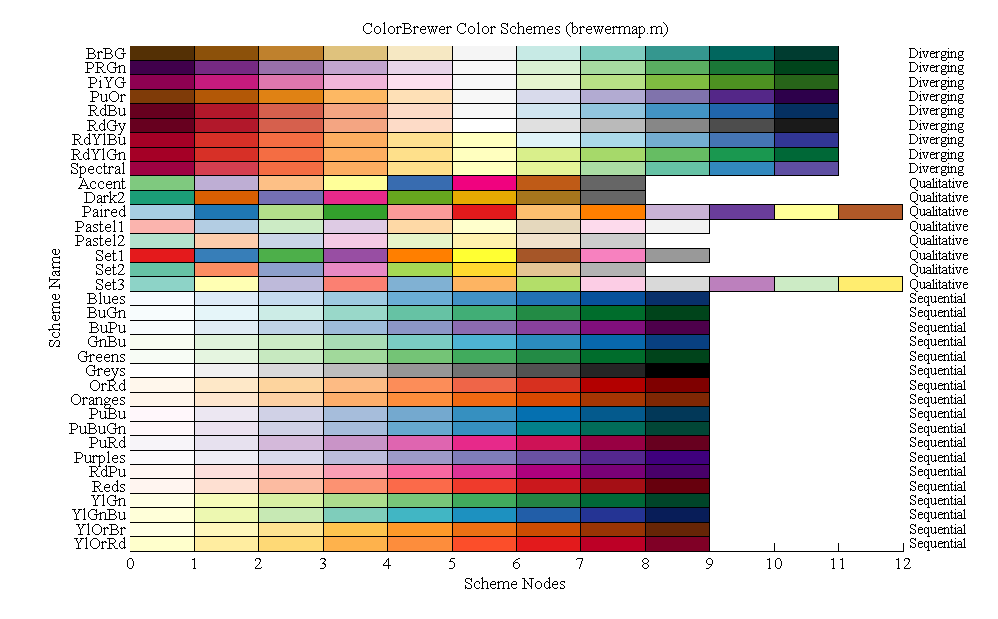

In [323]:
receitas_lojas = df_final.groupby('nome_loja')['valor_final'].sum().sort_values().reset_index()
display(receitas_lojas)

,nome_loja,valor_final
0,Filial MG,1824906.54
1,Filial SP,1877301.52
2,Filial ES,1958360.12
3,Loja Matriz,2168757.32


In [350]:
fig = px.bar(receitas_lojas, x='nome_loja', y='valor_final', title='Receitas por Loja', text=receitas_lojas['valor_final'], color='valor_final', color_continuous_scale=px.colors.diverging.Spectral)

fig.show()

In [354]:
fig = px.bar(receitas_lojas, x='nome_loja', y='valor_final', title='Receitas por Loja', text=receitas_lojas['valor_final'], color='valor_final', color_continuous_scale=px.colors.diverging.RdBu_r)
fig.update_traces(textposition='outside', texttemplate='%{text:.04s}')

fig.show()

In [351]:
qtd_prod = df_final.groupby('descricao_produto')['quantidade'].sum().sort_values(ascending=False).reset_index()


fig = px.bar(qtd_prod, x='descricao_produto', y='quantidade', text=qtd_prod['quantidade'],title='Quantidade de vendas por Produto', color='quantidade', color_continuous_scale=px.colors.sequential.Viridis)


fig.show()

In [356]:
fat_lojas = df_final.groupby('nome_loja').agg({
    'valor_final':'sum',
    'lucro':'sum'
}).sort_values(by='valor_final',ascending=False).reset_index()


fig = px.bar(
    fat_lojas,
    x= 'nome_loja',
    y=['valor_final','lucro'],
    barmode = 'group', text_auto=True,
    labels={'nome_loja': 'Nome Lojas'},
)


fig.update_traces(textposition='outside')


fig.show()

In [365]:
categorias = df_final['categoria'].value_counts().reset_index().sort_values(by='count', ascending=False)


fig = px.pie(categorias, names='categoria', values='count', height=500, width=500)


fig.update_traces(hole=0.1, pull=[0.3])
fig.show()

In [366]:
df_final['ano - mes'] = df_final['dt_venda'].dt.to_period('M')
df_fat_mes = df_final.groupby('ano - mes')['valor_final'].sum().reset_index()
df_fat_mes['ano - mes'] = df_fat_mes['ano - mes'].dt.to_timestamp()


fig = px.line(df_fat_mes, x='ano - mes', y='valor_final', line_shape='spline', markers='1')


fig.show()

In [367]:
lucro_vf = df_final.groupby('descricao_produto').agg({
    'valor_final':'sum',
    'lucro':'sum',
    'quantidade':'sum'
}).reset_index()

fig = px.scatter(lucro_vf, x='lucro', y='valor_final', color='descricao_produto', size='quantidade', size_max=25)

fig.show()

In [368]:
vendedores_geral = df_final.groupby(['nome_loja','nome_funcionario','descricao_produto'])['lucro'].sum().reset_index()

display(vendedores_geral)

fig = px.treemap(vendedores_geral, path=[px.Constant('Geral'),'nome_loja','nome_funcionario','descricao_produto'], values='lucro')

fig.show()

,nome_loja,nome_funcionario,descricao_produto,lucro
0,Filial ES,Mário Henrique,Aspirador de pó,5555.00
1,Filial ES,Mário Henrique,Batedeira,828.00
2,Filial ES,Mário Henrique,Cafeteira,2375.00
3,Filial ES,Mário Henrique,Cama Box,19868.80
4,Filial ES,Mário Henrique,Colchão,3080.00
...,...,...,...,...
235,Loja Matriz,Maria das Graças,Processador de alimentos,4074.90
236,Loja Matriz,Maria das Graças,Smartphone,38073.00
237,Loja Matriz,Maria das Graças,Sofá,15836.60
238,Loja Matriz,Maria das Graças,Tablet,33173.23


In [370]:
fig = px.sunburst(vendedores_geral, path=[px.Constant('Geral'),'nome_loja','nome_funcionario','descricao_produto'], values='lucro')

fig.show()